In [1]:
import labrad
from labrad import units
import numpy as np
import matplotlib.pyplot as plt
from os import path
import sys
import imageio
import scipy.optimize as opt
from scipy.optimize import curve_fit
from scipy import signal
from pylablib.devices import Thorlabs


import datetime
from pathlib import Path
import imutils

_root = path.abspath(path.join(
    '//arqusws-01', 'ArQuS Shared', 'LabRAD', 'LabRADCodes', 'servers', 'Spectrum_Card'))
sys.path.append(_root)


import wavegen as wg

#connecting to labrad
cxn = labrad.connect('192.168.1.21', password='ytterbium171')

In [2]:
MHz = 1e6
Mako_G_234_B = False
Mako_G_158_B = False
Thor_Cam = True

In [3]:
Thorlabs.list_cameras_tlcam()

['13286']

In [4]:
SC = cxn.m4i_6621_x8

if Thor_Cam == True:
    cam = Thorlabs.ThorlabsTLCamera('13286')
    cam.set_exposure(0.3*10**-3) # in seconds
    px = 3.45
    
elif Mako_G_234_B or Mako_G_158_B == True:
    #set exposure time
    MC = cxn.mako_camera
    print(MC.exposure_time(16 * units.us))
    print(MC.pixel_format('Mono8'))
    print(MC.gain(0 * units.dB))
    print(MC.frame_size(1936, 1216))
    px = 5.86

SC._reset()
SC._close()
SC._open()

#print list of server settings
# print(SC)
# print(MC)

In [5]:
# device info
print(f'found {SC._card_type()} with serial number {SC._serial_number()}')

# number of bytes per sample
print(f'number of bytes per sample: {SC._bytes_per_sample()}')

# # #enable channel 0
SC._enable_ch_0()

# #check number of opened channels
print(f'number of enabled channels: {SC._enabled_channel_count()}')

# check max sample rate
print(f'max sample rate provided by {SC._card_type()} is: {SC._max_sample_rate()/1e6} MHz')

# set sample rate
SC._sample_rate(np.int32(624*MHz))
sample_rate = SC._get_sample_rate()
print(f'sample rate set at: {sample_rate*1e-6} MHz')

#set memory size, min is 32, max 2GSample. Must be an integer multiple of 8.
SC._mem_size(np.int32(49920))
mem_size = SC._get_mem_size()
print(f'memory size set at: {mem_size}')

# set number of loops
SC._loops(int(0))

# #read number of loops
print(f'number of loops set to: {SC._get_loops()}')

# activate output of channel 0
SC._enable_out_CH0(True)
print(f'output of channel 0 is activated? {SC._get_enabled_out_CH0()}')

# set amplitude of CH 0
SC._amp_CH0(int(850))
print(f'amplitude of CH 0: {SC._get_amp_CH0()} mV')

# temperature of FPGA
print(f'temperature of FPGA: {SC._FPGA_temperature()}°C')

found M4i.6621-x8 with serial number 18494
number of bytes per sample: 2
number of enabled channels: 1
max sample rate provided by M4i.6621-x8 is: 625.0 MHz
sample rate set at: 624.0 MHz
memory size set at: 49920
number of loops set to: infinite
output of channel 0 is activated? True
amplitude of CH 0: 850 mV
temperature of FPGA: 58°C


In [12]:
#rounded resolution, defined as the ratio between
resolution = wg.frequency_resolution(mem_size, sample_rate)
print(f'wave resolution: {resolution}')

#define vector of tones
# tones_array = wg.tones_array(10, 70e6, 4e6)
tones_array = wg.tones_array(30, 68e6, 0.5e6)
print(f'frequencies: {tones_array * 1e-6} MHz')

#find resulting frequency and define sample rate
f_eq = np.gcd.reduce(tones_array.astype(np.int64))
print(f'resulting frequency (MCD): {f_eq*1e-6} MHz')

n_periods = f_eq/resolution
print(f'number of periods generated: {n_periods}')

# # this is used to have an idea  of the sample. It is not the wave that we send to the card, but just the first period of the wave
# fig = plt.subplots(1, figsize = (30, 6))
# plt.plot(wg.multi_tone(mem_size, sample_rate, tones_array)[:int((mem_size/n_periods))], marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod")
# plt.grid()
# plt.title('first period of the wave sent from PC to card')
# plt.tick_params(axis="y",direction="in")
# plt.tick_params(axis="x",direction="in")


wave resolution: 12500.0
frequencies: [68.  68.5 69.  69.5 70.  70.5 71.  71.5 72.  72.5 73.  73.5 74.  74.5
 75.  75.5 76.  76.5 77.  77.5 78.  78.5 79.  79.5 80.  80.5 81.  81.5
 82.  82.5] MHz
resulting frequency (MCD): 0.5 MHz
number of periods generated: 40.0


In [7]:
#define fitting functions
def gaussian_2D(xdata_tuple, amp, x0, y0, sigma_x, sigma_y):
    (x, y) = xdata_tuple
    G = amp * np.exp(-2 * ((x - x0) ** 2 / sigma_x ** 2 + (y - y0) ** 2 / sigma_y ** 2))
    return G.ravel()

def sum_of_2D_gaussians(xdata_tuple, *params):
    n = len(params) // 5  # Each Gaussian has 5 parameters: amp, x0, y0, sigma_x, sigma_y
    G = 0
    for i in range(n):
        amp, x0, y0, sigma_x, sigma_y = params[i * 5: ((i + 1) * 5)]
        G += gaussian_2D(xdata_tuple, amp, x0, y0, sigma_x, sigma_y)
    return G.ravel()

In [8]:
# RMS calculation
def RMS(wave):
    sq_elems = np.zeros((len(wave),), dtype = np.longdouble)
    for i in range(len(sq_elems)):
        sq_elems[i] = pow(wave[i], 2.0)
    return np.sqrt(1/(len(wave))*(np.sum(sq_elems)))

# distance from average value
def amplitude_mismatch(amp):
    M = np.mean(amp)
    return (amp[i] - M)/M

# feedback function
def new_RF_amp(RF_amp, p, error):
    return RF_amp - p * error

In [9]:
kitayoshi_phases = wg.kitayoshi_array(len(tones_array))
random_phases = wg.random_phases_array(len(tones_array))



###########################
__ STARTING CYCLE 1 __
###########################




Acquring image...


number of detected peaks: 30


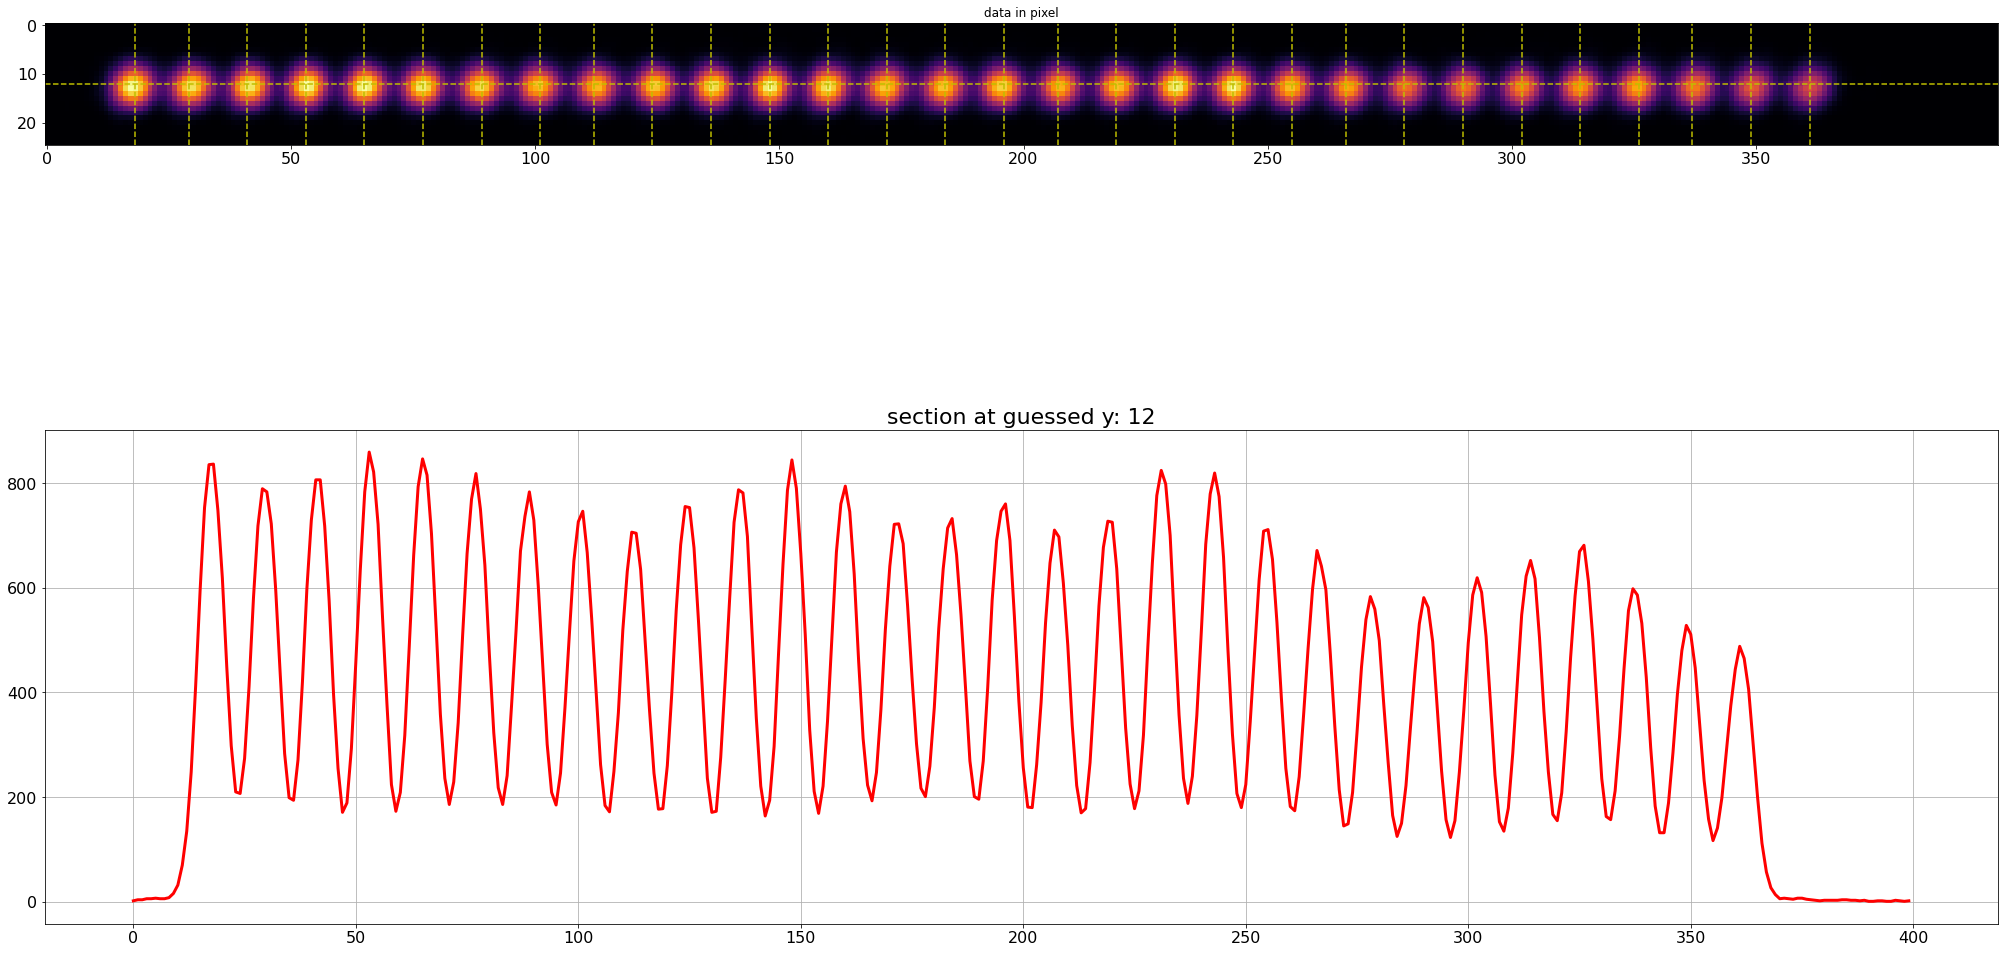



Fitting...


average amplitude: 757.797955
std amplitude: 99.70343016261873


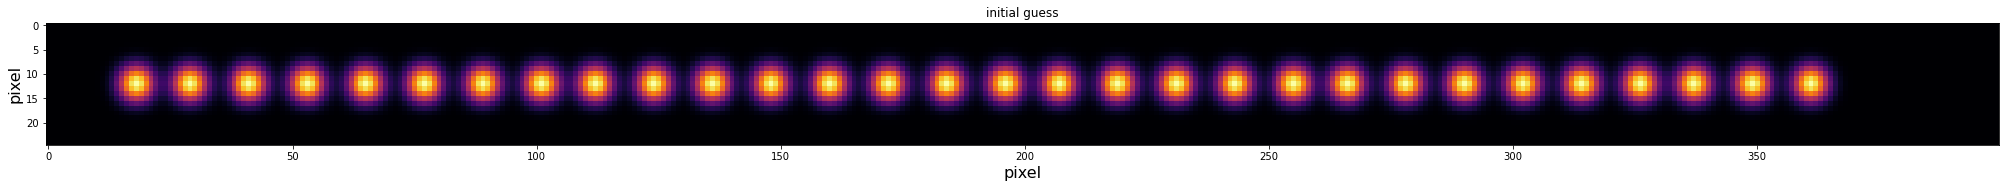

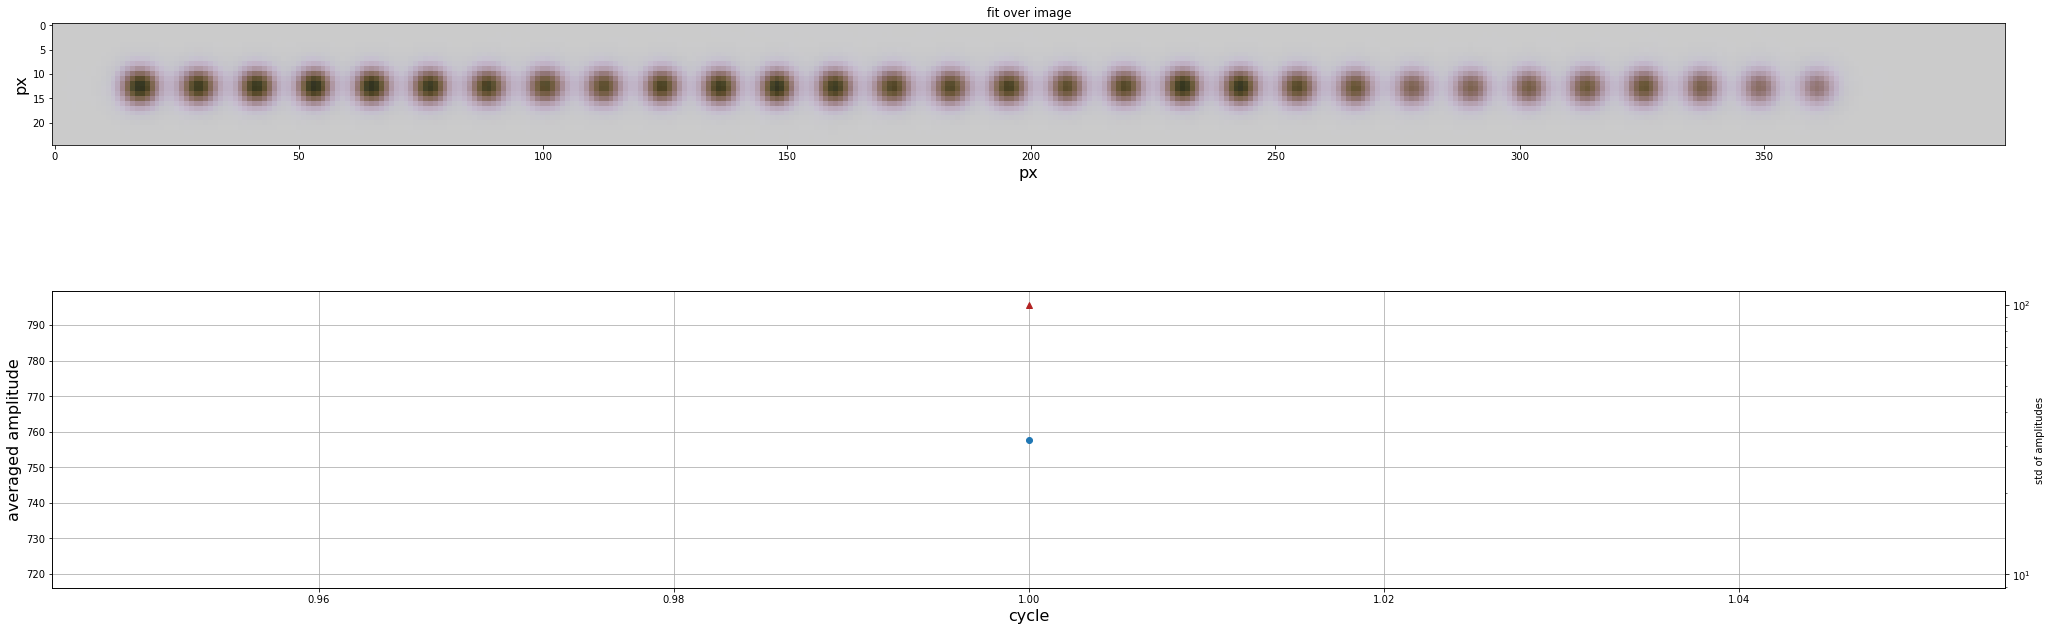

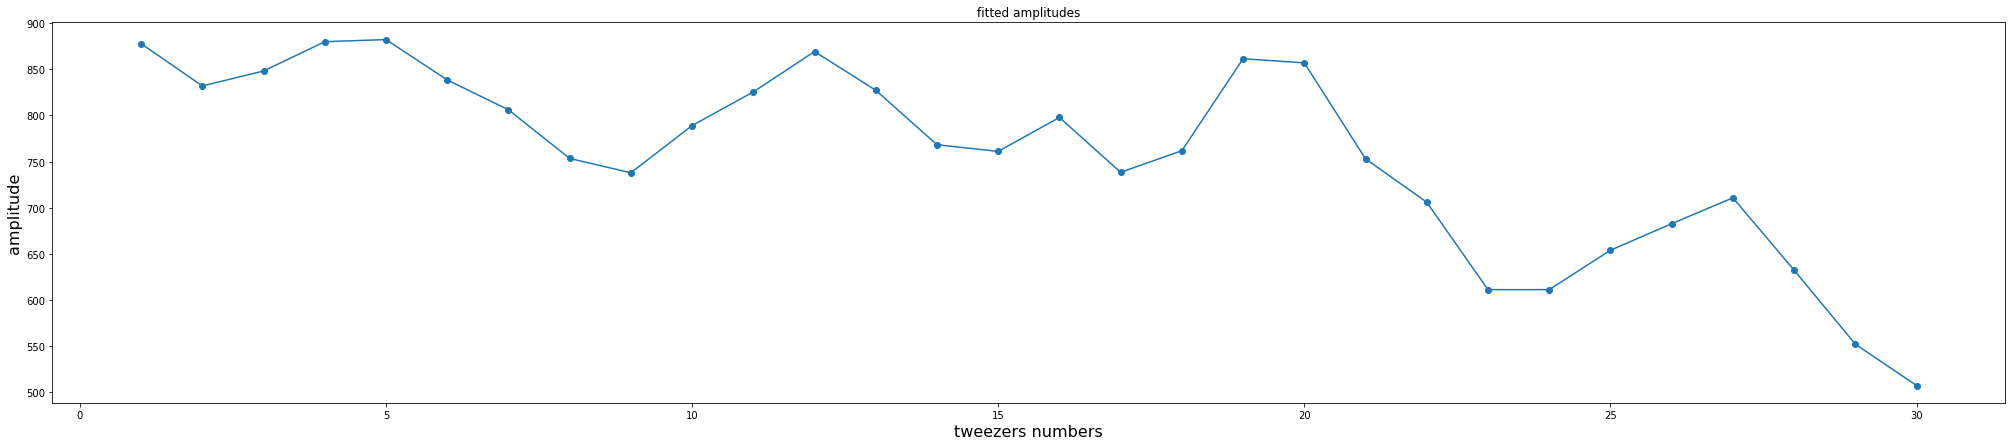

fitted amplitude array: [877.81493 831.95693 848.18383 879.92032 882.21696 838.47708 806.19351
 753.43692 737.88952 789.05206 825.50982 869.23821 827.28396 768.26389
 761.04835 797.84119 738.38992 761.83961 861.4683  856.98648 752.94485
 705.98743 611.26431 611.27934 653.97051 682.72655 710.77183 632.40521
 552.18191 507.39492]


error array: [ 0.158376  0.097861  0.119274  0.161154  0.164185  0.106465  0.063863
 -0.005755 -0.026271  0.041243  0.089353  0.147058  0.091695  0.013811
  0.004289  0.052842 -0.025611  0.005333  0.136805  0.13089  -0.006404
 -0.06837  -0.193368 -0.193348 -0.137012 -0.099065 -0.062056 -0.16547
 -0.271334 -0.330435]


p parameter: 0.02


old RF amplitude array: [0.033333 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333
 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333
 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333
 0.033333 0.033333 0.033333 0.033333 0.033333 0.033333]


new RF amplitude array: [0.

KeyboardInterrupt: 

In [ ]:
TWEEZERS_NUMBER = len(tones_array)
# we define a normalized initial RF amplitude array
RF_amp = np.zeros((len(tones_array),), dtype = np.float64)
for i in range(0, len(tones_array)):
    RF_amp[i] = 1/len(tones_array)

# RF_amp = [0.024885, 0.027868, 0.02875, 0.027495, 0.025919, 0.024774, 0.024348, 0.024439
# , 0.02398, 0.024239, 0.023762, 0.022496, 0.021117, 0.020907, 0.021548, 0.021944
# , 0.022072, 0.021632, 0.021074, 0.022101, 0.023239, 0.023787, 0.023951, 0.024783
# , 0.025395, 0.025637, 0.025675, 0.025125, 0.024318, 0.024376, 0.024507, 0.025723
# , 0.027733, 0.029095, 0.030038, 0.028745, 0.027478, 0.027529, 0.028588, 0.028927]





avg_amp = []
std_amp = []
rms_error = []
cycle_vec = []


# we start the feedback loop
for index in range(100):

    # SC._open()
    print('\n')
    print('###########################')
    print(f'__ STARTING CYCLE {index+1} __')
    print('###########################')
    print('\n')

    # transfers multitone array to card when the external trigger arrives
    SC._transfer_numpy_array_to_card(True, wg.multi_tone(mem_size, sample_rate, tones_array, RF_amp, kitayoshi_phases), True)
    SC._enable_trigger()
    SC._start_and_enable_trigger()

    # creates the path for the image and acquires it
    date_file = datetime.datetime.now()
    date_file = "%s.%s.%s.%s.%s.%s" % (date_file.year, date_file.month, date_file.day, date_file.hour, date_file.minute, date_file.second)

    __path__ = "//ARQUS-NAS/ArQuS Shared/Characterizations/Tweezers Analysis/tweezers_image/feedback_images/"
    filename = date_file
    fullpath = __path__ + str(filename)

    print('\n')
    print('Acquring image...')
    print('\n')

    if Mako_G_158_B or Mako_G_234_B == True:
        MC.frame_grab(fullpath, 'tif')
        img = imageio.imread(fullpath + '.tif')
        img = img[:, ::-1] #mirrors the image left right
        img = imutils.rotate(img, angle=2.15)
        img = img[635:655, 940:1900]

    elif Thor_Cam == True:
        img = cam.snap()
        # img = img[:, ::-1] #mirrors the image left right
        img = imutils.rotate(img, angle=-0.4)
        img = img[235:260, 200:600]
   

    # defines the grid of pixels
    rows = img.shape[0]
    cols = img.shape[1]
    x = np.arange(cols)
    y = np.arange(rows)
    x, y = np.meshgrid(x, y)

    # guessed parameters for the gaussians to fit
    amp = 120
    y0 = 12
    x0 = 0
    sigma_x = 5
    sigma_y = 5
    
    params = [amp, x0, y0, sigma_x, sigma_y] * TWEEZERS_NUMBER

# 
    # # # finds automatically the peaks
    peaks, _ = signal.find_peaks(img[y0, :], height = 20, distance = 7)

    # # build the x0 params with results found from the find_peaks function
    for i in range(int(len(params)/5)):
        params[1+(i*5)] = peaks[i]
    
    #plot the raw image and a section in the most peaked part
    fig, (ax1, ax2) = plt.subplots(2, figsize=(35, 20))
    ax1.imshow(img, interpolation='nearest', cmap='inferno')
    for j in range(len(peaks)):
         ax1.axvline(x = peaks[j], ls  = '--', linewidth = 1.5, color = 'y')

    ax1.axhline(y = y0, ls  = '--', linewidth = 1.5, color = 'y')
    ax1.xaxis.set_tick_params(labelsize=16)
    ax1.yaxis.set_tick_params(labelsize=16)
    ax1.set_title('data in pixel')

    #image in pixel
    # ax2.imshow(img, cmap='inferno')
    # ax2.imshow(img, extent=(0, cols*px, 0, rows*px), cmap='inferno')
    # ax2.set_xlabel('$\mu$m', fontsize=16)
    # ax2.set_ylabel('$\mu$m', fontsize=16)
    # # ax2.minorticks_on()
    # # ax2.grid(axis='y',which='both', ls='--')
    # ax2.set_title('data in micron')

    ax2.plot(img[y0, :], lw = 3, color = 'r')
    # ax2.plot(peaks, img[y0, :][peaks], "x", markersize=20, color = 'tab:blue')
    ax2.set_title(f'section at guessed y: {y0}', fontsize=22)
    ax2.xaxis.set_tick_params(labelsize=16)
    ax2.yaxis.set_tick_params(labelsize=16)
    ax2.grid()

    print(f'number of detected peaks: {len(peaks)}')
    plt.show()


    # feeds the function with the guessed parameters and plots the guessed image
    z = sum_of_2D_gaussians((x, y), *params).reshape(y.shape)

    fig, (ax3) = plt.subplots(1, figsize=(35, 7))
    ax3.imshow(z, cmap='inferno')
    ax3.set_xlabel('pixel', fontsize=16)
    ax3.set_ylabel('pixel', fontsize=16)
    ax3.set_title('initial guess')
    # ax3.grid()

    print('\n')
    print('Fitting...')
    print('\n')

    # init_guess = np.array(init_guess, dtype='float64')
    p_opt, cov = opt.curve_fit(sum_of_2D_gaussians, (x, y), img.ravel(), p0 = params)
    err = np.sqrt(np.diag(cov))

    # feeds the function with fitted parameters and plots fitted image over raw image
    data_fitted = sum_of_2D_gaussians((x, y), *p_opt).reshape(y.shape)

    fig, (ax4, ax5) = plt.subplots(2, figsize=(35, 12))
    ax4.imshow(img, cmap='inferno')
    ax4.imshow(data_fitted, cmap='Greys', alpha=0.8)
    ax4.set_xlabel('px', fontsize=16)
    ax4.set_ylabel('px', fontsize=16)
    ax4.set_title('fit over image')
    

    #creates lists of fitted values
    amp = []
    x0 = []
    y0 = []
    sigma_x = []
    sigma_y = []

    for i in range(TWEEZERS_NUMBER):
        amp.append(p_opt[0+(i*5)])
    amp = [round(i, 5) for i in amp]

    for i in range(TWEEZERS_NUMBER):
        x0.append(p_opt[1+(i*5)])
    x0 = [round(i, 5) for i in x0]

    for i in range(TWEEZERS_NUMBER):
        y0.append(p_opt[2+(i*5)])
    y0 = [round(i, 5) for i in y0]

    for i in range(TWEEZERS_NUMBER):
        sigma_x.append(p_opt[3+(i*5)])
    sigma_x = [round(i, 5) for i in sigma_x]

    for i in range(TWEEZERS_NUMBER):
        sigma_y.append(p_opt[4+(i*5)])
    sigma_y = [round(i, 5) for i in sigma_y]

    avg_amp.append(np.mean(amp))
    std_amp.append(np.std(amp))
    cycle_vec.append(index+1)

    # plot of average amplitude for each cycle
    ax5.plot(cycle_vec, avg_amp, 'o')
    ax5.set_xlabel('cycle', fontsize=16)
    ax5.set_ylabel('averaged amplitude', fontsize=16)
    ax5.grid()

    print(f'average amplitude: {avg_amp[-1]}')
    print(f'std amplitude: {std_amp[-1]}')

    
    # we build an error for each tweezers defined as the distance from the mean over the mean (percentage)
    error = []
    for i in range(len(amp)):
        error.append(amplitude_mismatch(amp))

    #we define an RMS error and we plot it
    amp = np.array(amp)
    error = np.array(error)
    rms_error.append(RMS(error))

    #plot of the RMS error for each cycle
    ax6 = ax5.twinx()
    ax6.semilogy(cycle_vec, std_amp, '^', color = 'firebrick')
    ax6.set_ylabel('std of amplitudes')
    plt.show()
    
    #definition of p gain. Here we are doing a scaling of the p parameters that changes when the RMS error becomes very small
    # p = np.full(shape=len(tones_array), fill_value=0.001, dtype=float)
    # p = np.abs((error - np.mean(error))*1e-2)
    p = 0.02
    # if std_amp[-1] < 30:
    #     p = 0.0008

    fig, (ax7) = plt.subplots(1, figsize=(35, 7))
    tweezers_index_array = np.arange(1, TWEEZERS_NUMBER+1, 1)
    ax7.plot(tweezers_index_array, amp, '-o')
    ax7.set_xlabel('tweezers numbers', fontsize=16)
    ax7.set_ylabel('amplitude', fontsize=16)
    ax7.set_title('fitted amplitudes')
    plt.show()

    print(f'fitted amplitude array: {np.round(amp, 6)}')
    print('\n')
    print(f'error array: {np.round(error, 6)}')
    print('\n')
    print(f'p parameter: {np.round(p, 6)}')
    print('\n')
    # print(f'RMS error: {np.round(rms_error[-1], 6)}')
    # print('\n')
    print(f'old RF amplitude array: {np.round(RF_amp, 6)}')
    print('\n')   
    # overwrites the RF_amp vector with a new RF vector corrected by the feedback
    RF_amp = np.round(new_RF_amp(RF_amp, p, error), 6)
    print(f'new RF amplitude array: {RF_amp}')
    print('\n')



SC._close()

In [12]:
SC._close()